In [1]:
import pandas as pd
import random
from scipy.stats import norm
import numpy as np
import matplotlib.pyplot as plt

A=pd.read_csv("population_A.csv")
B=pd.read_csv("population_B.csv")
marges_V=pd.read_csv("marges_V.csv")

##### Question 1

In [2]:
cols=["i","G","S","U","V"]
print(A[cols].equals(B[cols]))

True


##### Question 2.d

In [3]:
def simulation(population,n=800,M=500,alpha=0.05):
    N=len(population)
    p_chapeau=[]
    p=population["Y"].mean()
    RMSE=0
    proportion=0
    longueurs=[]
    z=norm.ppf(1-alpha/2)
    for i in range(M):
        indices=random.sample(range(N),n) # n numéros de ligne distincts parmi 0, ..., N-1
        R=population.iloc[indices]
        p_chapeau_i=R["Y"].mean()
        RMSE+=(p_chapeau_i-p)**2
        p_chapeau.append(p_chapeau_i)
        var_hat=(1-n/N)*p_chapeau_i*(1-p_chapeau_i)/(n-1)
        demi_longueur=z*np.sqrt(var_hat)
        if np.abs(p_chapeau_i-p)<=demi_longueur:
            proportion+=1
        longueurs.append(2*demi_longueur)

    longueurs=np.array(longueurs)
    longueur_moy=longueurs.mean()
    proportion=proportion/M
    RMSE=np.sqrt(RMSE/M)
    p_chapeau=np.array(p_chapeau)
    moyenne=p_chapeau.mean()
    biais_empirique=moyenne-p
    variance_empirique=p_chapeau.var()

    return(moyenne,biais_empirique,variance_empirique,RMSE,proportion,longueur_moy,p_chapeau)

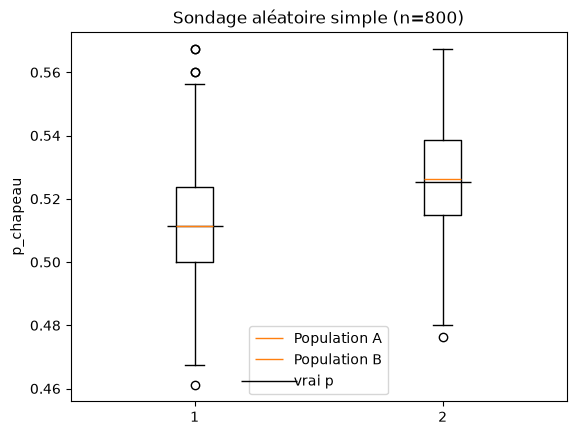

In [6]:
plt.boxplot([simulation(A)[6],simulation(B)[6]],label=["Population A","Population B"])
plt.plot(1,A["Y"].mean(),"k_",markersize=40,label="vrai p")
plt.plot(2,B["Y"].mean(),"k_",markersize=40)
plt.ylabel("p_chapeau")
plt.title("Sondage aléatoire simple (n=800)")
plt.legend()
plt.show()

##### Question 5

In [8]:
def allocation(N_h, S_h, n, n_min=2):
    strates=list(N_h.keys())
    H=len(strates)
    poids=np.array([N_h[h]*S_h[h] for h in strates],dtype=float)
    if poids.sum() == 0:                 # tous les S_h estimés sont nuls
        poids=np.array([N_h[h] for h in strates],dtype=float)   # → proportionnelle

    reste=n-n_min*H  #allouer le reste
    cible=reste*poids/poids.sum()  # parts non entières
    n_alloc=np.floor(cible).astype(int)
    manque=reste-n_alloc.sum()   # unités perdues à l'arrondi
    ordre=np.argsort(-(cible-n_alloc))   # plus grandes parties décimales d'abord
    n_alloc[ordre[:manque]] += 1
    n_alloc+=n_min  #garantir que chaque n_h>=2
    return dict(zip(strates, n_alloc))

In [9]:
def calcul(strates,d,b,N):
    p_strat=0
    var_strat=0
    for h, g in strates:
            indices=random.sample(range(len(g)),d[h])
            echantillon_h=g.iloc[indices]
            Y_h=echantillon_h["Y"]
            Y_h_barre=np.sum(Y_h)/d[h]
            W_h=b[h]/N
            S2_h=np.sum((Y_h-Y_h_barre)**2)/(d[h]-1)
            p_strat+=W_h*Y_h_barre
            var_strat+=W_h**2*((1-d[h]/b[h])*S2_h/d[h])
    return p_strat,var_strat
    

In [10]:
def comparer(population,n=800,M=500,alpha=0.05):
    strates=population.groupby(["G","S","U"])
    N=len(population)
    N_h={h: len(g) for h, g in strates} #dictionnaire strate:effectif
    p_strat=[]
    var_strat=[]
    #Méthode proportionnelle
    n_h_prop=allocation(N_h,{h: 1 for h in N_h},n)
    
    #Methode Neyman_Oracle
    Y_strates={h:g["Y"].tolist() for h,g in strates}
    S_oracle={}
    for h,Y in Y_strates.items():
        p_h=sum(Y)/len(Y)                        
        somme=0
        for y in Y:
            somme+=(y-p_h)**2
        S_oracle[h]=np.sqrt(somme/(len(Y)-1))
    n_h_oracle=allocation(N_h,S_oracle,n)
    
    for rep in range(M):
        p_strat_methodes=[]
        var_strat_methodes=[]
        #Méthode proportionnelle
        p_strat_prop,var_strat_prop=calcul(strates,n_h_prop,N_h,N)
        
        p_strat_methodes.append(p_strat_prop)
        var_strat_methodes.append(var_strat_prop)
        
        #Méthode Neyman_Pilote
        S_pilote={}
        for h,groupe in strates:
            indices=random.sample(range(len(groupe)),20)
            pilote_h=groupe.iloc[indices]
            Y_pilote_h=pilote_h["Y"]
            p=Y_pilote_h.mean()
            S_Y_h=0
            for y in Y_pilote_h:
                S_Y_h+=(y-p)**2
            S_Y_h=np.sqrt(S_Y_h/19)
            S_pilote[h]=S_Y_h
        n_h=allocation(N_h,S_pilote,n)
        p_strat_pilote,var_strat_pilote=calcul(strates,n_h,N_h,N)
        
        p_strat_methodes.append(p_strat_pilote)
        var_strat_methodes.append(var_strat_pilote)
        
        #Methode Neyman_Oracle
        p_strat_oracle,var_strat_oracle=calcul(strates,n_h_oracle,N_h,N)
        
        p_strat_methodes.append(p_strat_oracle)
        var_strat_methodes.append(var_strat_oracle)
        
        p_strat.append(p_strat_methodes)
        var_strat.append(var_strat_methodes)
        
    p=population["Y"].mean()
    z=norm.ppf(1-alpha/2)
    P=np.array(p_strat)        # P[k,j]=p_strat de la répétition k, méthode j
    V=np.array(var_strat)      # V[k,j]=var_strat de la répétition k, méthode j
    demi_longueur=z*np.sqrt(V)                     # demi-longueur[k,j], demi-longueur de la répétition k, méthode j
    couvre = np.abs(P-p)<=demi_longueur            

    return(P.mean(axis=0),P.mean(axis=0)-p,P.var(axis=0),np.sqrt(((P-p)**2).mean(axis=0)),couvre.mean(axis=0),(2*demi_longueur).mean(axis=0),P)

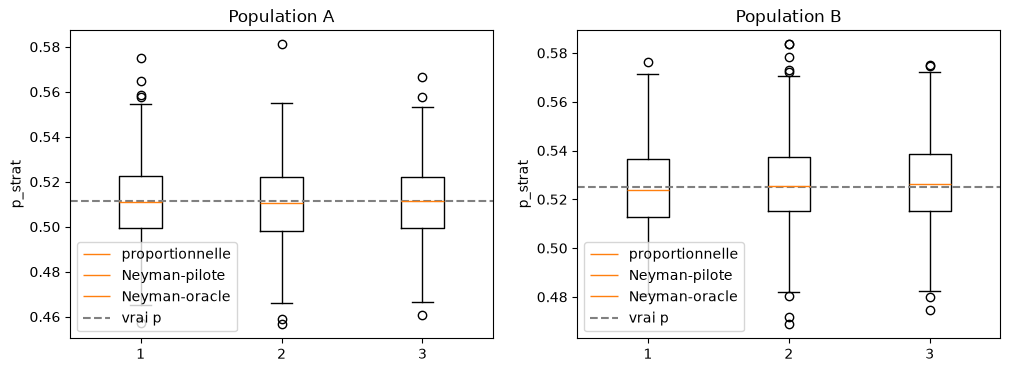

In [12]:
noms=["proportionnelle","Neyman-pilote","Neyman-oracle"]
fig,ax=plt.subplots(1,2,figsize=(12,4))
for j,(nom,pop) in enumerate([("A",A),("B",B)]):
    P=comparer(pop)[6]
    ax[j].boxplot([P[:,k] for k in range(3)],label=noms)
    ax[j].axhline(pop["Y"].mean(),color="gray",linestyle="--",label="vrai p")
    ax[j].set_title("Population "+nom)
    ax[j].set_ylabel("p_strat")
    ax[j].legend()
plt.show()